In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("plots.mplstyle")

# Rabi oscillations: measurement18

6 repeats were attempted; any repeat whose `mw_us` grid doesn't match the others (e.g. from a resonance-tracking drift mid-scan) is excluded before combining. The plotted curve is the per-point median of R over the remaining repeats (median rather than mean so a single still-bad repeat can't skew a point).

In [2]:
RABI_DIR = Path(r"D:\rabi\measurement18")
RABI_PREFIX = "measurement18"


def load_rabi_repeats(data_dir, prefix):
    """Load every repeat's mw_us/X/Y. Returns a list of
    {"repeat": i, "mw_us": ..., "r": ...} dicts."""
    repeats = []
    for mw_file in sorted(data_dir.glob(f"{prefix}_repeat*_rabi_mw_us.npy")):
        repeat_id = mw_file.stem.split("_repeat")[1].split("_")[0]
        mw_us = np.load(mw_file)
        x = np.load(data_dir / f"{prefix}_repeat{repeat_id}_rabi_x.npy")
        y = np.load(data_dir / f"{prefix}_repeat{repeat_id}_rabi_y.npy")
        repeats.append({"repeat": repeat_id, "mw_us": mw_us, "r": np.hypot(x, y)})
    return repeats


def exclude_grid_mismatches(repeats):
    """Keep only repeats whose mw_us grid matches the most common grid
    (by shape then value). Prints which repeats, if any, were dropped."""
    grids = [tuple(r["mw_us"]) for r in repeats]
    common_grid = max(set(grids), key=grids.count)
    kept, dropped = [], []
    for repeat, grid in zip(repeats, grids):
        (kept if grid == common_grid else dropped).append(repeat)
    if dropped:
        print(f"excluded {len(dropped)} repeat(s) with a grid mismatch: " +
              ", ".join(r["repeat"] for r in dropped))
    else:
        print("no grid mismatches")
    print(f"{len(kept)} repeat(s) kept: " + ", ".join(r["repeat"] for r in kept))
    return kept

no grid mismatches
5 repeat(s) kept: 0, 1, 2, 3, 4


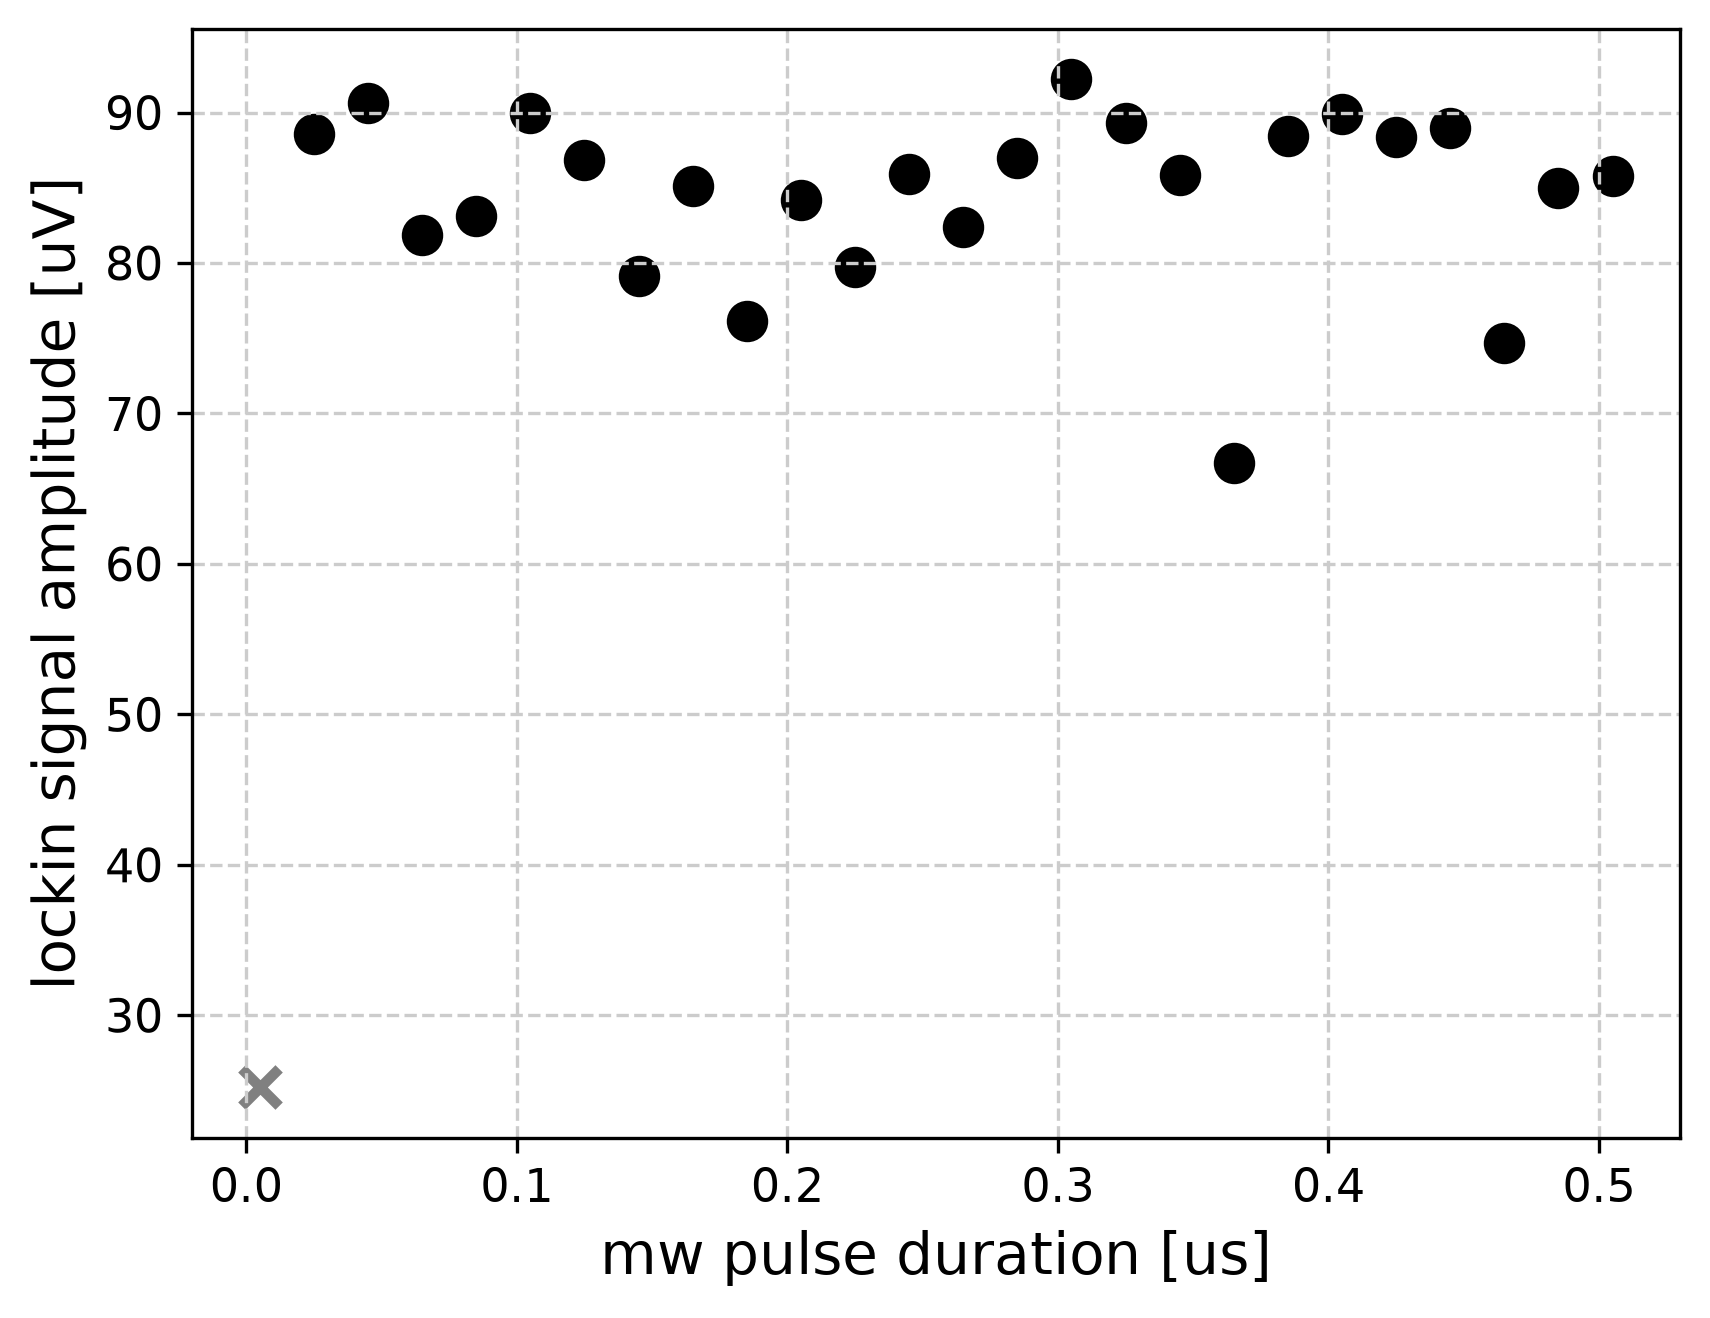

In [3]:
UNRELIABLE_PULSE_CUTOFF_US = 0.02  # below this, pulse shape at this speed isn't trustworthy

rabi_repeats = load_rabi_repeats(RABI_DIR, RABI_PREFIX)
kept_repeats = exclude_grid_mismatches(rabi_repeats)

mw_us = kept_repeats[0]["mw_us"]
r_median_uv = np.median([repeat["r"] for repeat in kept_repeats], axis=0) * 1e6

unreliable = mw_us < UNRELIABLE_PULSE_CUTOFF_US

fig, ax = plt.subplots(dpi=300)
ax.scatter(mw_us[~unreliable], r_median_uv[~unreliable], color="black", s=80)
ax.scatter(mw_us[unreliable], r_median_uv[unreliable], color="gray", marker="x", s=80)
ax.set_xlabel("mw pulse duration [us]")
ax.set_ylabel("lockin signal amplitude [uV]")
plt.show()